# **Delhi Air Quality Analysis, Part 1: $\text{NO}_2$ Spatial Analysis (Summer 2019-2024)**

*This notebook contains the data acquisition, processing, visualization, and analysis for the Sentinel-5P NO₂ study of Delhi: Delhi boundary clipping, year-wise spatial maps, hotspot detection, and conclusions (Tasks 1.1 to 1.4).*

# **Pre-Requisite Setup**

**Install Libraries, Authenticate, and Initialize GEE**
**This cell installs all necessary libraries and handles the Google Earth Engine (GEE) authentication.**
**Since Colab runtimes can disconnect, running ee.authenticate()** **first ensures the connection is refreshed.**

In [ ]:
!pip install earthengine-api rioxarray xarray numpy pandas geopandas fiona

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 1.8 MB/s eta 0:00:00


# **Authenticate GEE and Initialize the Google Cloud project**

In [ ]:
import ee

ee.Authenticate()
PROJECT_ID = "your-gee-project-id"  # replace with your own Google Cloud project ID
ee.Initialize(project=PROJECT_ID)

print("Authentication and Initialization successful! You can now proceed to run the analysis scripts.")

Authentication and Initialization successful! You can now proceed to run the analysis scripts.


# **Extract and Download Sentinel-5P Summer NO₂ Mean for Delhi (2019–2024)**

**This Extracts Sentinel-5P NO₂ data for a Delhi region (2019–2024), computes summer seasonal means for each year, stacks them into a multi-band image, and generates a download link for the resulting GeoTIFF.**

In [ ]:
import ee
import xarray as xr
import rioxarray as rxr
import numpy as np

START_YEAR = 2019
END_YEAR = 2024
TARGET_BAND = 'NO2_column_number_density'
S5P_NO2 = ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')


WEST_NEW = 76.0
SOUTH_NEW = 27.5
EAST_NEW = 78.25
NORTH_NEW = 29.5
delhi_aoi_buffered = ee.Geometry.Rectangle([WEST_NEW, SOUTH_NEW, EAST_NEW, NORTH_NEW])
print(f"Using AOI: [{WEST_NEW}, {SOUTH_NEW}, {EAST_NEW}, {NORTH_NEW}]")


yearly_mean_images = []
print("Calculating mean NO2 for summer months (Mar, Apr, May, Jun) for 2019-2024...")

for year in range(START_YEAR, END_YEAR + 1):
    start_date = ee.Date(f'{year}-03-01')
    end_date = ee.Date(f'{year}-06-30')

    summer_collection = S5P_NO2.filterDate(start_date, end_date) \
                               .filterBounds(delhi_aoi_buffered) \
                               .select(TARGET_BAND)

    mean_image = summer_collection.mean()
    mean_image = mean_image.set('system:index', f'{year}')
    yearly_mean_images.append(mean_image)

yearly_collection = ee.ImageCollection(yearly_mean_images)


stacked_image = yearly_collection.toBands()
new_download_url = stacked_image.getDownloadURL({
    'name': 'NO2_Summer_Mean_BUFFERED_2019_2024',
    'region': delhi_aoi_buffered.getInfo()['coordinates'],
    'filetype': 'GEO_TIFF',
    'scale': 1113.2,
    'format': 'GEO_TIFF'
})

print("\n--- NEW DOWNLOAD INSTRUCTIONS ---")
print("1. Click the link below to download the NEW buffered data:")
print(new_download_url)

Using AOI: [76.0, 27.5, 78.25, 29.5]
Calculating mean NO2 for summer months (Mar, Apr, May, Jun) for 2019-2024...

--- NEW DOWNLOAD INSTRUCTIONS ---
1. Click the link below to download the NEW buffered data:
https://earthengine.googleapis.com/v1/projects/your-gee-project-id/thumbnails/5d090bf9b35460a64dfadd39cd572439-828b800a5ec7d427a2eca026a37a72d9:getPixels


# **Task 1.1: Trim Dataset to Delhi Boundary Using Shapefile**

*This cell loads the downloaded NO₂ GeoTIFF, loads the Delhi boundary shapefile, and masks the raster to clip the dataset strictly to the Delhi boundary, saving the result for further analysis and visualization.*

**Delhi Shapefile Download Link (GADM)**
* We get this shape file from GADM (trusted source)
* Step 1: https://gadm.org/download_country.html
* Step 2: https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IND_1.json.zip
* Step 3: Upload the ZIP file to the colab

In [ ]:
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
import pandas as pd
import numpy as np
from rasterio.mask import mask
from rasterio.features import geometry_mask

print("Loading saved Xarray Data...")
new_file_path = 'NO2_Summer_Mean_BUFFERED_2019_2024.tiff'
local_zip_path = "gadm41_IND_1.json.zip"
TARGET_CRS = 4326

START_YEAR = 2019
END_YEAR = 2024
TARGET_BAND = 'NO2_column_number_density'

xds = rxr.open_rasterio(new_file_path, chunks='auto')
xds = xds.rename({'band': 'year'})
xds['year'] = np.arange(START_YEAR, END_YEAR + 1)
xds.name = TARGET_BAND
xds = xds.where(xds != xds.rio.nodata)

print("Loading local India shapefile and filtering for NCT of Delhi...")
india_gdf = gpd.read_file(f"zip://{local_zip_path}")
delhi_gdf = india_gdf[india_gdf['NAME_1'] == 'NCT of Delhi'].copy()

if delhi_gdf.crs.to_epsg() != TARGET_CRS:
    delhi_gdf = delhi_gdf.to_crs(epsg=TARGET_CRS)

print("Trimming/Masking the NO2 dataset to the Delhi boundary...")


xds = xds.rio.write_crs(TARGET_CRS)

geoms = delhi_gdf.geometry.to_list()

mask_array = geometry_mask(geoms,
                           out_shape=xds.shape[1:],
                           transform=xds.rio.transform(),
                           all_touched=True,
                           invert=False)

mask_array = np.broadcast_to(mask_array, xds.shape)

xds_masked = xds.where(~mask_array)


print("\n Dataset successfully masked and trimmed to Delhi boundary!")
print("\n Clipped Xarray Dataset Information")
print(xds_masked)


xds_clipped = xds_masked
xds_clipped.to_netcdf("NO2_Data_Clipped.nc")
print("\nClipped data saved as NO2_Data_Clipped.nc.")

Loading saved Xarray Data...
Loading local India shapefile and filtering for NCT of Delhi...
Trimming/Masking the NO2 dataset to the Delhi boundary...

 Dataset successfully masked and trimmed to Delhi boundary!

 Clipped Xarray Dataset Information
<xarray.DataArray 'NO2_column_number_density' (year: 6, y: 201, x: 226)> Size: 2MB
dask.array<where, shape=(6, 201, 226), dtype=float64, chunksize=(1, 201, 226), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2024
  * y            (y) float64 2kB 29.5 29.49 29.48 29.47 ... 27.52 27.51 27.5
  * x            (x) float64 2kB 76.0 76.01 76.02 76.03 ... 78.23 78.24 78.25
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

Clipped data saved as NO2_Data_Clipped.nc.


# **Task 1.2: Visualize Year-wise NO₂ Spatial Distribution for Delhi (2019–2024)**

**This cell loads the clipped NO₂ dataset and the downloaded Delhi boundary shapefile (gadm41_IND_1.json.zip), then generates spatial plots for each year to analyze how summer NO₂ levels have changed temporally and spatially across Delhi.**

Loading Raster Data: NO2_Summer_Mean_BUFFERED_2019_2024.tiff
Loading India GADM (zip): gadm41_IND_1.json.zip
Raster CRS: EPSG:4326
Reprojected Delhi boundary to raster CRS.
Trimming/Masking the NO2 dataset to the Delhi boundary...
DataArray info:
<xarray.DataArray 'NO2_column_number_density' (year: 6, y: 201, x: 226)> Size: 2MB
dask.array<where, shape=(6, 201, 226), dtype=float64, chunksize=(1, 201, 226), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2024
  * y            (y) float64 2kB 29.5 29.49 29.48 29.47 ... 27.52 27.51 27.5
  * x            (x) float64 2kB 76.0 76.01 76.02 76.03 ... 78.23 78.24 78.25
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0
Colorbar limits (scaled by 1000000000000000.0): vmin=9.339e+10, vmax=2.037e+11


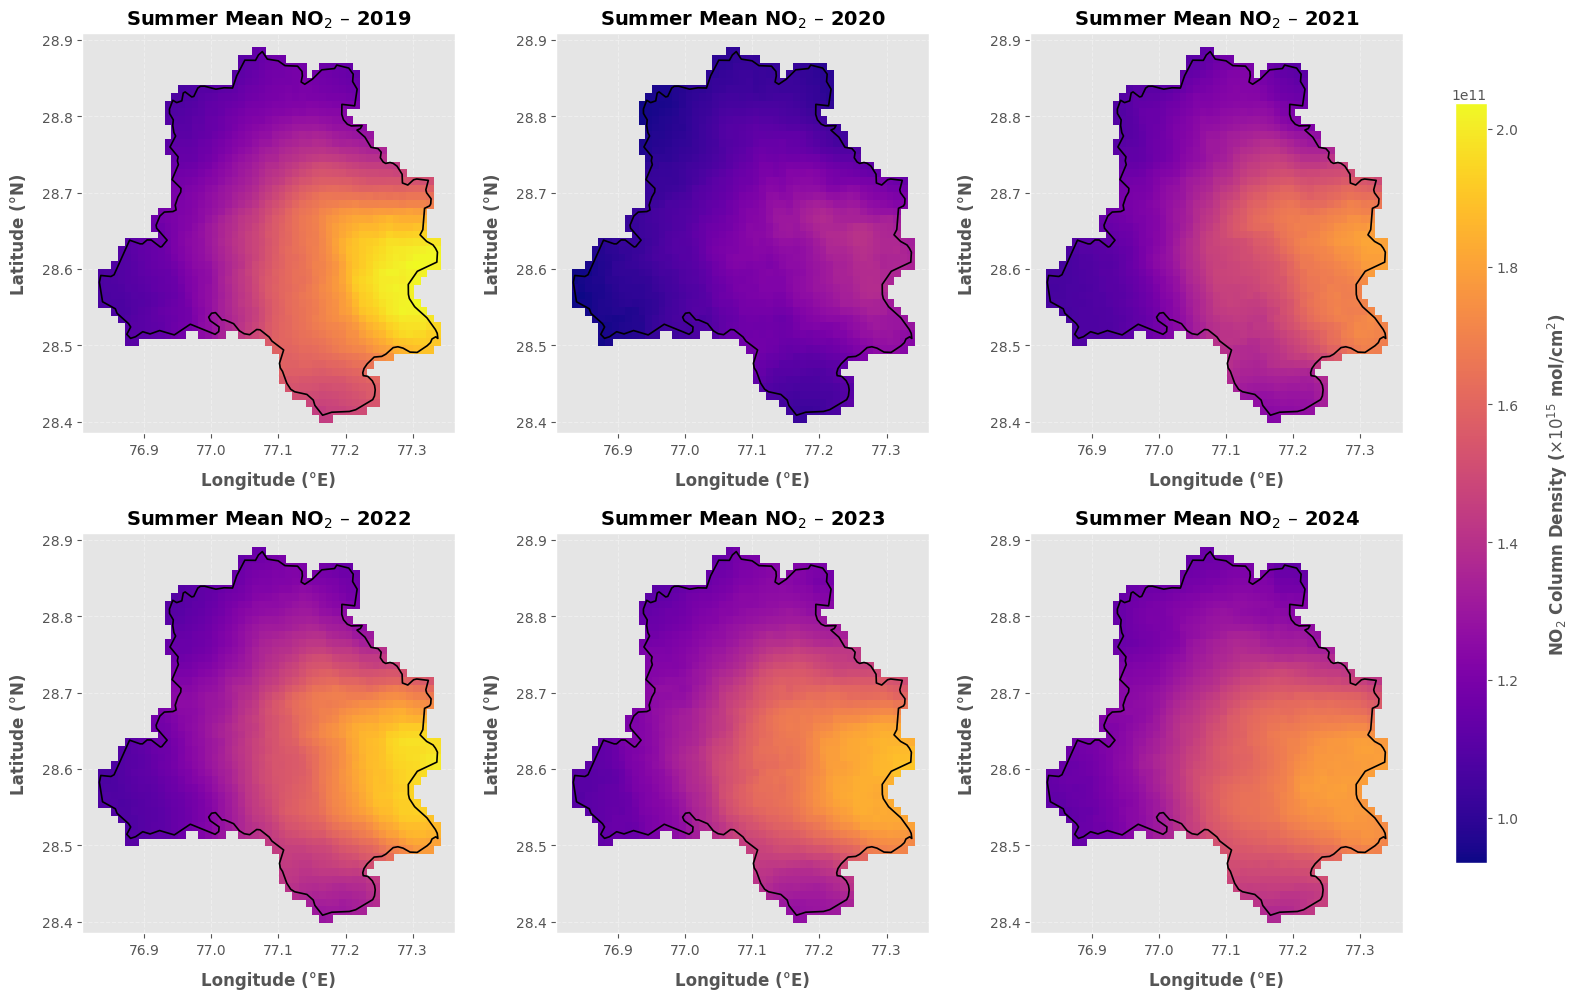


 Plotting finished successfully.


In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import os
import warnings
import rioxarray

DATA_PATH = "NO2_Summer_Mean_BUFFERED_2019_2024.tiff"
GADM_ZIP = "gadm41_IND_1.json.zip"
START_YEAR = 2019
END_YEAR = 2024
TARGET_BAND = 'NO2_column_number_density'


def load_data_array_robust(path):
    da = rioxarray.open_rasterio(path, chunks='auto')
    da = da.rename({'band': 'year'})
    da['year'] = np.arange(START_YEAR, END_YEAR + 1)
    da.name = TARGET_BAND

    if da.rio.nodata is not None:
        da = da.where(da != da.rio.nodata)

    return da

print("Loading Raster Data:", DATA_PATH)
da = load_data_array_robust(DATA_PATH)

print("Loading India GADM (zip):", GADM_ZIP)
india_gdf = gpd.read_file(f"zip://{GADM_ZIP}")

delhi_boundary = india_gdf[india_gdf['NAME_1'].str.contains('Delhi', case=False, na=False)]
if delhi_boundary.empty:
    delhi_boundary = india_gdf[india_gdf['NAME_1'] == 'NCT of Delhi']
if delhi_boundary.empty:
    raise RuntimeError("Could not find Delhi (NCT of Delhi) in the provided gadm file.")

raster_crs = None
try:
    if getattr(da, "rio", None) is None or da.rio.crs is None:
        da = da.rio.write_crs("EPSG:4326")
    raster_crs = da.rio.crs
    print("Raster CRS:", raster_crs)
except Exception:
    print("rioxarray failed to set CRS. Assuming EPSG:4326.")
    da = da.rio.write_crs("EPSG:4326")
    raster_crs = da.rio.crs

try:
    delhi_boundary = delhi_boundary.to_crs(raster_crs)
    print("Reprojected Delhi boundary to raster CRS.")
except Exception:
    warnings.warn("Failed to reproject Delhi boundary to raster CRS. Clipping might fail.")

print("Trimming/Masking the NO2 dataset to the Delhi boundary...")
from rasterio.features import geometry_mask
geoms = delhi_boundary.geometry.to_list()
mask_array = geometry_mask(geoms,
                            out_shape=da.shape[1:],
                            transform=da.rio.transform(),
                            all_touched=True,
                            invert=False)
da_clipped = da.where(~np.broadcast_to(mask_array, da.shape))
da = da_clipped.copy()


print("DataArray info:")
print(da)

da = da.where(np.isfinite(da))

SCALE = 1e15
da_scaled = da * SCALE

da_filtered = da_scaled.where(da_scaled > 0)

p_low, p_high = 1, 99
try:
    vmin = float(da_filtered.quantile(p_low / 100.0, dim=["x", "y"], skipna=True).quantile(0.5).item())
    vmax = float(da_filtered.quantile(p_high / 100.0, dim=["x", "y"], skipna=True).quantile(0.5).item())
except Exception:
    vmin = np.nanmin(da_filtered.values)
    vmax = np.nanmax(da_filtered.values)

if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
    raise SystemExit("Cannot plot: calculated VMIN/VMAX range is invalid (data may be all NaN).")

if vmin < 0.1:
    vmin = 0.1

print(f"Colorbar limits (scaled by {SCALE}): vmin={vmin:.4g}, vmax={vmax:.4g}")

minx, miny, maxx, maxy = delhi_boundary.total_bounds
x_range = maxx - minx
y_range = maxy - miny

x_buffer = x_range * 0.05
y_buffer = y_range * 0.05
xlims = (minx - x_buffer, maxx + x_buffer)
ylims = (miny - y_buffer, maxy + y_buffer)

years = list(da_scaled['year'].values)
num_years = len(years)
ncols = 3
nrows = int(np.ceil(num_years / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows), constrained_layout=False)
axes = np.array(axes).reshape(-1)

plt.style.use('ggplot')
last_img = None
unit_label = r'NO$_2$ Column Density ($\times 10^{15}$ mol/cm$^2$)'

for i, year in enumerate(years):
    ax = axes[i]
    arr = da_scaled.sel(year=year)

    img = arr.plot.pcolormesh(
        ax=ax,
        x='x', y='y',
        cmap='plasma',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        edgecolor='face'
    )
    last_img = img

    ax.set_xlim(xlims)
    ax.set_ylim(ylims)

    ax.set_aspect('equal')

    try:
        delhi_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2)
    except Exception:
        warnings.warn("Could not overlay Delhi boundary. Proceeding without boundary line.")

    ax.set_title(f"Summer Mean NO$_2$ – {int(year)}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Longitude (°E)", labelpad=10, fontweight='bold')
    ax.set_ylabel("Latitude (°N)", labelpad=10, fontweight='bold')

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    ax.grid(True, linestyle='--', alpha=0.35)

for j in range(num_years, len(axes)):
    fig.delaxes(axes[j])

cbar_ax = fig.add_axes([0.92, 0.12, 0.02, 0.76])
cb = fig.colorbar(last_img, cax=cbar_ax)
cb.set_label(unit_label, fontweight='bold', labelpad=20)

plt.subplots_adjust(left=0.05, right=0.9, top=0.95, bottom=0.05, hspace=0.25, wspace=0.15)
plt.show()

print("\n Plotting finished successfully.")

# **Task 1.3: Develop and Visualize NO₂ Hotspot Detection Methodology**

**This cell applies a hybrid hotspot identification method using the clipped NO₂ dataset. The approach combines a percentile-based threshold (90th percentile absolute concentration) and a local statistical anomaly filter (Z-score method) to detect persistent high-pollution zones. The detected hotspots are visualized on a spatial map using Python to support interpretation of spatial pollution patterns.**

Loading clipped data for hybrid analysis...
Calculating Hybrid Hotspot Mask...
90th Percentile (T_abs): 1.703e+11


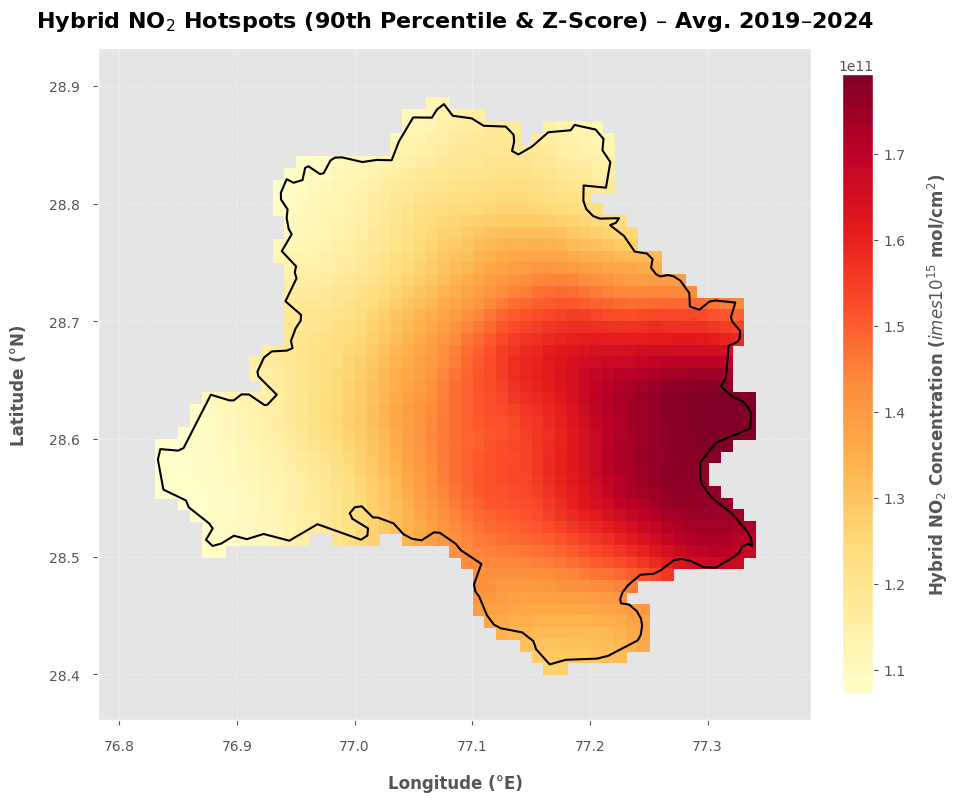


 Hybrid Hotspot visualization and calculation successful.


In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import rioxarray
from scipy.ndimage import uniform_filter
import warnings

DATA_PATH = "NO2_Summer_Mean_BUFFERED_2019_2024.tiff"
TARGET_BAND = 'NO2_column_number_density'
START_YEAR = 2019
END_YEAR = 2024
SCALE = 1e15

def load_and_clip_data():
    warnings.filterwarnings("ignore")

    da = rioxarray.open_rasterio(DATA_PATH, chunks='auto')
    da = da.rename({'band': 'year'})
    da['year'] = np.arange(START_YEAR, END_YEAR + 1)
    da.name = TARGET_BAND
    if da.rio.nodata is not None: da = da.where(da != da.rio.nodata)

    GADM_ZIP = "gadm41_IND_1.json.zip"
    india_gdf = gpd.read_file(f"zip://{GADM_ZIP}")
    delhi_boundary = india_gdf[india_gdf['NAME_1'].str.contains('Delhi', case=False, na=False)]
    if delhi_boundary.empty: delhi_boundary = india_gdf[india_gdf['NAME_1'] == 'NCT of Delhi']

    da = da.rio.write_crs("EPSG:4326")
    delhi_boundary = delhi_boundary.to_crs(da.rio.crs)

    from rasterio.features import geometry_mask
    geoms = delhi_boundary.geometry.to_list()
    mask_array = geometry_mask(geoms, out_shape=da.shape[1:], transform=da.rio.transform(), all_touched=True, invert=False)
    da_clipped = da.where(~np.broadcast_to(mask_array, da.shape))

    return da_clipped, delhi_boundary


print("Loading clipped data for hybrid analysis...")
xds_clipped, delhi_boundary = load_and_clip_data()
xds_scaled = xds_clipped * SCALE
xds_filtered = xds_scaled.where(xds_scaled > 0)

data_avg_6yr = xds_filtered.mean(dim='year', skipna=True).compute()


print("Calculating Hybrid Hotspot Mask...")

T_abs = data_avg_6yr.stack(z=('x', 'y')).quantile(0.90, skipna=True).compute().item()
print(f"90th Percentile (T_abs): {T_abs:.4g}")
abs_mask = data_avg_6yr >= T_abs


Z_crit = 1.0
window_size = 5
data_np = data_avg_6yr.values.astype(np.float64)
local_mean = uniform_filter(data_np, size=window_size, mode='nearest')
local_variance = uniform_filter(data_np**2, size=window_size, mode='nearest') - local_mean**2
local_variance[local_variance < 1e-12] = 1e-12
local_std = np.sqrt(local_variance)
z_score = (data_np - local_mean) / local_std
z_score_xda = data_avg_6yr.copy(data=z_score)
z_score_mask = z_score_xda >= Z_crit

hotspot_mask = abs_mask & z_score_mask
hotspot_data = data_avg_6yr.where(hotspot_mask)

fig, ax = plt.subplots(figsize=(10, 10))

bg_vmin = data_avg_6yr.quantile(0.01, skipna=True).item()
bg_vmax = data_avg_6yr.quantile(0.99, skipna=True).item()
if bg_vmin < 0.1: bg_vmin = 0.1

xmin, ymin, xmax, ymax = delhi_boundary.total_bounds
x_buffer = (xmax - xmin) * 0.10
y_buffer = (ymax - ymin) * 0.10

img = data_avg_6yr.plot.pcolormesh(
    ax=ax, cmap='YlOrRd',
    vmin=bg_vmin, vmax=bg_vmax,
    add_colorbar=False, edgecolor='face'
)

delhi_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

ax.set_aspect('equal')
ax.set_xlim(xmin - x_buffer, xmax + x_buffer)
ax.set_ylim(ymin - y_buffer, ymax + y_buffer)

ax.set_title("Hybrid NO$_2$ Hotspots (90th Percentile & Z-Score) – Avg. 2019–2024",
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Longitude (°E)", labelpad=15, fontweight='bold')
ax.set_ylabel("Latitude (°N)", labelpad=15, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.35)
ax.tick_params(axis='x', labelsize=10, pad=10)
ax.tick_params(axis='y', labelsize=10, pad=10)

cb = fig.colorbar(img, ax=ax, orientation='vertical', fraction=0.04, pad=0.04)

cb.set_label('Hybrid NO$_2$ Concentration ($\times 10^{15}$ mol/cm$^2$)', fontweight='bold', labelpad=15)

plt.show()


print("\n Hybrid Hotspot visualization and calculation successful.")

# **Task 1.4: Conclusions**

**Understanding NO₂ Pollution in Delhi (2019–2024, Summer Season)**

*Our analysis of Sentinel-5P satellite data provides a clear picture of how NO₂ levels in Delhi have changed over time and where the pollution is most concentrated.*

## **1. Human Activity Strongly Influences NO₂ Levels**

*The data shows a direct link between human activities and NO₂ concentrations. A noticeable drop in 2020 during the COVID-19 lockdown, followed by a steady increase from 2022 onward, confirms that emissions mainly come from vehicles, industries, and other human-driven sources.*

* **What it means:** *As life and the economy returned to normal, so did high pollution levels — indicating that current pollution control efforts are not reducing emissions sustainably.*

## **2. Pollution is Concentrated in Specific High-Risk Zones**

*The spatial pattern is not random. The same regions repeatedly show high NO₂ levels year after year.*

* **Major hotspot:** *Eastern and South-Eastern parts of Delhi, especially near busy transport corridors and industrial clusters.*

* **What it means:** *Pollution is tied to fixed sources, not city-wide background emissions.*

## **3. Poor Atmospheric Dispersion Makes Some Areas Worse**

*The Z-score anomaly analysis shows that some hotspot areas have significantly higher NO₂ compared to their surroundings. This suggests the pollutants are not dispersing well and continue to accumulate.*

* **What it means:** *Even moderate emissions in these zones can lead to severe air quality problems because the atmosphere struggles to disperse pollutants.*

## **4. Policy Needs to Move from General Restrictions to Targeted Interventions**

*Based on the findings, broad pollution control strategies are not enough.*
* **Recommended approach:**
*Implement stricter, localized measures — especially for transport and industrial emissions — in regions repeatedly identified as hotspots.*

## **Final Insight**

*Delhi’s NO₂ problem is not city-wide; it is persistent, localized, and strongly linked to human activity.
Meaningful improvement will only happen if policies focus on the specific high-risk areas where emissions and poor dispersion combine to create severe air quality hotspots.*